In [2]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict

In [3]:
class joke_state(TypedDict):

    topic : str
    joke : str
    explanation : str

In [4]:
load_dotenv()

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation"
)

model = ChatHuggingFace(llm=llm)

c:\Users\Dell\anaconda3\envs\LangGraph_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
def generate_joke(state: joke_state) -> joke_state:

    prompt = f"Generate a small joke on the topic :{state['topic']}"

    result = model.invoke(prompt)

    return {'joke' : result.content}


def generate_explanation(state: joke_state) -> joke_state:

    prompt = f"I want the easiest explanation of this joke \n {state['joke']}"

    result = model.invoke(prompt)

    return {'explanation': result.content}

In [23]:
checkpointer= InMemorySaver()

In [24]:
# Creating the graph!!!

graph = StateGraph(joke_state)

graph.add_node('joke', generate_joke)
graph.add_node('explanation', generate_explanation)

graph.add_edge(START, 'joke')
graph.add_edge('joke', 'explanation')
graph.add_edge('explanation', END)

workflow = graph.compile(checkpointer=checkpointer)

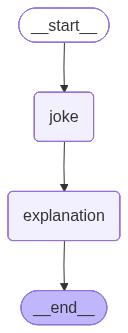

In [25]:
workflow

In [26]:
config1 = {"configurable": {"thread_id" : "1"}}
result = workflow.invoke({'topic':'Noodles'}, config=config1)

In [27]:
print(result)

{'topic': 'Noodles', 'joke': 'Why did the noodle go to therapy? Because it was feeling a little "twisted."', 'explanation': 'The joke is a play on words. "Twisted" has a double meaning here:\n\n1. The noodle is a type of food that can be twisted or curved in shape.\n2. "Feeling a little twisted" is also an idiom that means feeling emotionally disturbed or unstable.\n\nSo, the joke is saying that the noodle went to therapy because it was feeling emotionally unstable, but the punchline is also referencing the noodle\'s physical shape, making it a lighthearted and silly joke.'}


In [28]:
workflow.get_state(config=config1)

StateSnapshot(values={'topic': 'Noodles', 'joke': 'Why did the noodle go to therapy? Because it was feeling a little "twisted."', 'explanation': 'The joke is a play on words. "Twisted" has a double meaning here:\n\n1. The noodle is a type of food that can be twisted or curved in shape.\n2. "Feeling a little twisted" is also an idiom that means feeling emotionally disturbed or unstable.\n\nSo, the joke is saying that the noodle went to therapy because it was feeling emotionally unstable, but the punchline is also referencing the noodle\'s physical shape, making it a lighthearted and silly joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13a844-2631-688c-8002-8f22a69d2b34'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-17T17:38:34.908057+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13a844-2064-6609-8001-02d2c6195064'}}, tasks=(), interrupts=())

In [30]:
list(workflow.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'Noodles', 'joke': 'Why did the noodle go to therapy? Because it was feeling a little "twisted."', 'explanation': 'The joke is a play on words. "Twisted" has a double meaning here:\n\n1. The noodle is a type of food that can be twisted or curved in shape.\n2. "Feeling a little twisted" is also an idiom that means feeling emotionally disturbed or unstable.\n\nSo, the joke is saying that the noodle went to therapy because it was feeling emotionally unstable, but the punchline is also referencing the noodle\'s physical shape, making it a lighthearted and silly joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13a844-2631-688c-8002-8f22a69d2b34'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-17T17:38:34.908057+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13a844-2064-6609-8001-02d2c6195064'}}, tasks=(), interrupts=()),
 Stat

In [31]:
workflow.get_state(config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13a844-193f-6021-8000-b46d87dd4236'}})

StateSnapshot(values={'topic': 'Noodles'}, next=('joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13a844-193f-6021-8000-b46d87dd4236'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-17T17:38:33.550431+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13a844-1939-6abc-bfff-3ac336c04a7f'}}, tasks=(PregelTask(id='c3b41a2c-0fa6-cc29-fa5c-bdb87c4b3168', name='joke', path=('__pregel_pull', 'joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the noodle go to therapy? Because it was feeling a little "twisted."'}),), interrupts=())

In [34]:
list(workflow.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'Noodles', 'joke': 'Why did the noodle go to therapy? Because it was feeling a little "twisted."', 'explanation': 'The joke is a play on words. "Twisted" has a double meaning here:\n\n1. The noodle is a type of food that can be twisted or curved in shape.\n2. "Feeling a little twisted" is also an idiom that means feeling emotionally disturbed or unstable.\n\nSo, the joke is saying that the noodle went to therapy because it was feeling emotionally unstable, but the punchline is also referencing the noodle\'s physical shape, making it a lighthearted and silly joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13a844-2631-688c-8002-8f22a69d2b34'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-17T17:38:34.908057+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13a844-2064-6609-8001-02d2c6195064'}}, tasks=(), interrupts=()),
 Stat

In [35]:
workflow.invoke(None, config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13a844-193f-6021-8000-b46d87dd4236'}})

{'topic': 'Noodles',
 'joke': 'Why did the noodles go to therapy? \n\nBecause they were feeling a little "twisted" and wanted to work through their "spaghetti" of emotions.',
 'explanation': 'The joke is making a play on words. It\'s saying the noodles went to therapy because they were feeling a bit mixed up or "twisted" (like knotted noodles). Then it references their "spaghetti" emotions, which is a pun on the fact that spaghetti is a type of noodle. It\'s a lighthearted, wordplay-based joke.'}

In [36]:
list(workflow.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'Noodles', 'joke': 'Why did the noodles go to therapy? \n\nBecause they were feeling a little "twisted" and wanted to work through their "spaghetti" of emotions.', 'explanation': 'The joke is making a play on words. It\'s saying the noodles went to therapy because they were feeling a bit mixed up or "twisted" (like knotted noodles). Then it references their "spaghetti" emotions, which is a pun on the fact that spaghetti is a type of noodle. It\'s a lighthearted, wordplay-based joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13a885-df77-6ef8-8002-9ddaa8eef40b'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-17T18:07:59.166014+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f13a885-d9e6-6787-8001-7b92d150e8ba'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'Noodles', 'joke': 'Why did the noodles go to therapy? 

In [39]:
from langchain_core.messages import HumanMessage, AIMessage
model.invoke([HumanMessage(content="What is the capital of India?")])

AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 42, 'total_tokens': 51}, 'model_name': 'meta-llama/Llama-3.1-8B-Instruct', 'system_fingerprint': 'fp_f3ef9115178b5033ce85', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d9f07-28a6-71d1-9071-0e901b9f9a00-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 9, 'total_tokens': 51})